# AI-Based Help Desk System
## Ticket Classification Model

**Project:** ResolveAI Help Desk

**Task:** Ticket Classification

**Prepared by:** Talha, Imran

**Environment:** VS Code + Jupyter Notebook

**Objective:**
Train a Machine Learning model that automatically predicts the department/category of a support ticket based on its title and description.

---

# Step 1 - Import Required Libraries

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 2 - Load the Dataset

In [3]:
df = pd.read_csv("../data/support_tickets.csv")

# Step 3 - Check Dataset Shape

In [4]:
print ("Shapes of Dataset" , df.shape)

Shapes of Dataset (474, 4)


# Step 4 - Check first rows

In [5]:
df.head(10)

,ticket_id,description,category,priority
0,TCK-0001,My uploaded thesis file keeps getting corrupte...,Portal Technical Issue,High
1,TCK-0002,Sir I submitted my degree application form but...,Degree,Medium
2,TCK-0003,My semester fee unpaid chalan not shown on por...,Fee & Challan,Medium
3,TCK-0004,A major water leakage has flooded part of the ...,Infrastructure / Maintenance,Critical
4,TCK-0005,What is the process to apply for a duplicate d...,Degree,Low
5,TCK-0006,I have a visa interview tomorrow morning and m...,Employee Services,Critical
6,TCK-0007,"I want to join, please guide how.",Other,Low
7,TCK-0008,My admission has been put on hold because my H...,Admission,High
8,TCK-0009,What is the fee for issuing a character certif...,Certificate / Verification,Low
9,TCK-0010,Kindly guide me on the renewal process for my ...,Scholarship,Medium


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ticket_id    474 non-null    str  
 1   description  474 non-null    str  
 2   category     474 non-null    str  
 3   priority     474 non-null    str  
dtypes: str(4)
memory usage: 14.9 KB


# Step 6 - Explore the Target Variable (Category)

In [7]:
# Display all unique categories

print("Unique Categories:")
print(df["category"].unique())

Unique Categories:
<StringArray>
[      'Portal Technical Issue',                       'Degree',
                'Fee & Challan', 'Infrastructure / Maintenance',
            'Employee Services',                        'Other',
                    'Admission',   'Certificate / Verification',
                  'Scholarship',                   'Transcript',
                       'Thesis',              'Name Correction',
              'Account & Login',               'Profile Update',
                    'Complaint',                       'Result',
                  'Examination',          'Course Registration',
                    'Clearance']
Length: 19, dtype: str


# Step 7 - Count Total Categories

In [8]:
# Count unique categories

print("Total Categories:", df["category"].nunique())

Total Categories: 19


# Step 8 - Category Distribution

In [9]:
# Count tickets in each category

category_counts = df["category"].value_counts()

print(category_counts)

category
Portal Technical Issue          25
Degree                          25
Fee & Challan                   25
Infrastructure / Maintenance    25
Employee Services               25
Other                           25
Admission                       25
Certificate / Verification      25
Scholarship                     25
Transcript                      25
Thesis                          25
Name Correction                 25
Profile Update                  25
Complaint                       25
Result                          25
Examination                     25
Course Registration             25
Clearance                       25
Account & Login                 24
Name: count, dtype: int64


# Step 9: Check for duplicate tickets

In [10]:
duplicate_rows = df.duplicated().sum()
print("number of duplicate rows:", duplicate_rows)

number of duplicate rows: 0


# Step 10: Check for null description

In [11]:
# Display 10 random ticket descriptions with their categories

df[["description", "category"]].sample(10, random_state=42)

,description,category
428,The result declaration module has crashed for ...,Portal Technical Issue
440,When does course registration open for the nex...,Course Registration
9,Kindly guide me on the renewal process for my ...,Scholarship
468,asslam o Alaikum I hope you are doing well sir...,Clearance
39,Sir mera transcript voucher pay ho chuka hai l...,Transcript
33,Kindly tell me the fee structure for MBA.,Fee & Challan
461,Kindly change my registered email address on m...,Account & Login
280,My profile shows a completely wrong CNIC that ...,Profile Update
82,My account has been hacked and someone changed...,Account & Login
55,My profile shows a completely wrong CNIC that ...,Profile Update


# Step 11 - Analyze description length

In [12]:
df["description_length"] = df["description"].str.len()

print("Minimum length:", df["description_length"].min())
print("Maximum length:", df["description_length"].max())
print("Average length:", round(df["description_length"].mean(), 2))

Minimum length: 14
Maximum length: 1378
Average length: 174.99


# Step 13 - Define input and target

In [13]:
x = df["description"]
y = df["category"]

print("input (x)", x.shape)
print("Target (y)", y.shape)



input (x) (474,)
Target (y) (474,)


# Step 14 - Split dataset into test and train

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state= 42,
    stratify = y
)

print("Training samples:", len(x_train))
print("Testing_samples", len(x_test))

Training samples: 379
Testing_samples 95


# Step 15 - TF-IDF vectorizer

In [15]:
tfidf = TfidfVectorizer(
    lowercase= True,
    ngram_range= (1,2),
    min_df= 1,
    max_df= 0.95,
    sublinear_tf= True
    )  


# Step 16 -  Transform training text with TF-IDF

In [16]:
x_train_tfidf = tfidf.fit_transform(x_train)
print(x_train_tfidf.shape)

(379, 6708)


# Step 17 - Transform test text with TF_IDF

In [17]:

x_test_tfidf = tfidf.transform(x_test)

print("Test TF-IDF shape:", x_test_tfidf.shape)

Test TF-IDF shape: (95, 6708)


# Step 18 - train baseline logistic regression

In [18]:

# Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model``
logistic_model.fit(x_train_tfidf, y_train)



,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# Step 19 - Generate prdictions

In [19]:
y_pred = logistic_model.predict(x_test_tfidf)

print("Number of predictions", len(y_pred))

Number of predictions 95


# Step 20 - Check accuracy

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: " , round(accuracy, 4))
print("Accuracy (%)" , round(accuracy * 100 , 2), "%")

Accuracy:  0.8632
Accuracy (%) 86.32 %


# Step 21 - Classification report

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                              precision    recall  f1-score   support

             Account & Login       0.71      1.00      0.83         5
                   Admission       0.83      1.00      0.91         5
  Certificate / Verification       1.00      0.80      0.89         5
                   Clearance       0.83      1.00      0.91         5
                   Complaint       1.00      1.00      1.00         5
         Course Registration       0.80      0.80      0.80         5
                      Degree       0.80      0.80      0.80         5
           Employee Services       1.00      0.60      0.75         5
                 Examination       0.71      1.00      0.83         5
               Fee & Challan       0.75      0.60      0.67         5
Infrastructure / Maintenance       1.00      1.00      1.00         5
             Name Correction       0.83      1.00      0.91         5
                       Other       0.80      0.80      0.80         5
      Portal Techni

# Step 22 - Confusion matrix

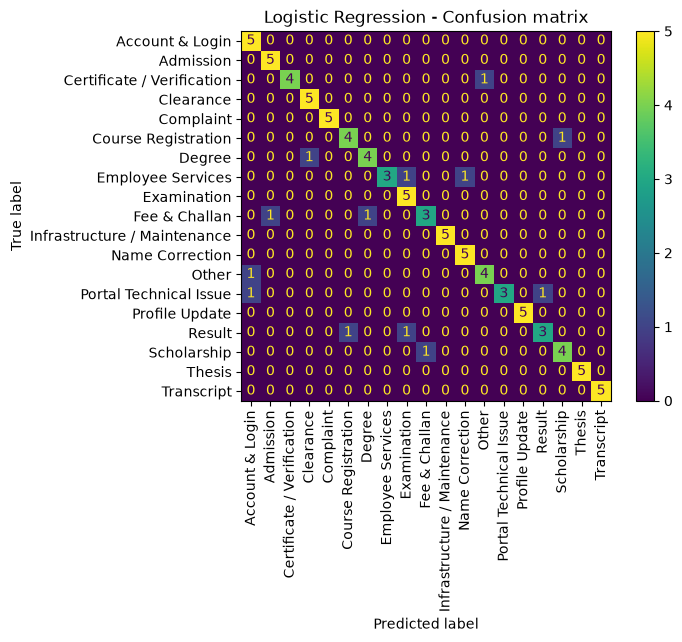

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation = "vertical"
)
plt.title("Logistic Regression - Confusion matrix")
plt.tight_layout
plt.show()


# Step 23 - Record baseline model

In [23]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_test, y_pred, average= "macro")
print("Model : Logistic Regression")
print("Accuracy:" , round(accuracy * 100 , 2) , "%")
print("Macro f1-score:", round(macro_f1, 4))

Model : Logistic Regression
Accuracy: 86.32 %
Macro f1-score: 0.8587


# Step 24 - Train a linear SVM model

In [24]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(
    random_state = 42
)

svm_model.fit(x_train_tfidf, y_train)
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# Step 25 - Generate SVM Prediction

In [25]:
y_pred_svm = svm_model.predict(x_test_tfidf)
print("Number of predictions: " , len(y_pred_svm))

Number of predictions:  95


# Step 26 - Evaluate Linear SVM

In [26]:
from sklearn.metrics import accuracy_score, f1_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_macro_f1 = f1_score(y_test, y_pred_svm, average= "macro")

print("Linear SVM")
print("Accuracy: ", round(svm_accuracy * 100, 2), "%")
print("Macro F1-score: ", round(svm_macro_f1, 4))

Linear SVM
Accuracy:  88.42 %
Macro F1-score:  0.8806


# Step 27 - Compare Baseline Models

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        macro_f1,
        svm_macro_f1
    ]
})

comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.863158,0.858745
1,Linear SVM,0.884211,0.880569


# Step 28 - Cross-Validation

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    x_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("Cross-validation Macro F1 scores:")
print(logistic_cv_scores)

print("Mean Macro F1:", round(logistic_cv_scores.mean(), 4))
print("Standard Deviation:", round(logistic_cv_scores.std(), 4))

Cross-validation Macro F1 scores:
[0.64090909 0.79675704 0.84649123 0.87589808 0.82783474]
Mean Macro F1: 0.7976
Standard Deviation: 0.0824


# Step 29 - Cross-Validate Linear SVM

In [29]:
svm_cv_scores = cross_val_score(
    svm_model,
    x_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("SVM Cross-validation Macro F1 scores:")
print(svm_cv_scores)

print("Mean Macro F1:", round(svm_cv_scores.mean(), 4))
print("Standard Deviation:", round(svm_cv_scores.std(), 4))

SVM Cross-validation Macro F1 scores:
[0.71547049 0.83485228 0.87740184 0.86370092 0.87761069]
Mean Macro F1: 0.8338
Standard Deviation: 0.0612


# Step 30 - Compare Cross-Validation Results

In [30]:
cv_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Mean Macro F1": [
        logistic_cv_scores.mean(),
        svm_cv_scores.mean()
    ],
    "Std Macro F1": [
        logistic_cv_scores.std(),
        svm_cv_scores.std()
    ]
})

cv_comparison

,Model,Mean Macro F1,Std Macro F1
0,Logistic Regression,0.797578,0.082447
1,Linear SVM,0.833807,0.061184


# Step 31 - Create the parameter Grid

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}
print("Parameter values to test:" , param_grid)

Parameter values to test: {'C': [0.01, 0.1, 1, 10, 100]}


# Step 32 - Find Best SVM Hyperparameters

In [32]:
grid_search = GridSearchCV(
    estimator = LinearSVC(random_state=42),
    param_grid = param_grid,
    scoring = "f1_macro",
    cv = cv,
    n_jobs= -1
)
grid_search.fit(x_train_tfidf, y_train)

print("Best Parameters:", grid_search.best_params_)
print ("Best Macro F1:", round(grid_search.best_score_, 4))

Best Parameters: {'C': 10}
Best Macro F1: 0.8383


# Step 33 - Get best SVM model

In [33]:
best_svm_model = grid_search.best_estimator_

print("Best SVM model:")
print(best_svm_model)

Best SVM model:
LinearSVC(C=10, random_state=42)


# Step 34 - Evaluate tuned SVM on test data

In [34]:
# Generate predictions using the tuned SVM

y_pred_best = best_svm_model.predict(x_test_tfidf)

# Calculate final test metrics
final_accuracy = accuracy_score(y_test, y_pred_best)
final_macro_f1 = f1_score(y_test, y_pred_best, average="macro")

print("Tuned Linear SVM")
print("Accuracy:", round(final_accuracy * 100, 2), "%")
print("Macro F1-score:", round(final_macro_f1, 4))

Tuned Linear SVM
Accuracy: 88.42 %
Macro F1-score: 0.8811


# Step 35 - Final classification report

In [35]:
print("Final Tunned SVM classification report")
print()

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

Final Tunned SVM classification report

                              precision    recall  f1-score   support

             Account & Login       0.83      1.00      0.91         5
                   Admission       1.00      1.00      1.00         5
  Certificate / Verification       1.00      0.80      0.89         5
                   Clearance       0.83      1.00      0.91         5
                   Complaint       1.00      1.00      1.00         5
         Course Registration       1.00      0.80      0.89         5
                      Degree       0.67      0.80      0.73         5
           Employee Services       1.00      0.60      0.75         5
                 Examination       0.71      1.00      0.83         5
               Fee & Challan       1.00      0.60      0.75         5
Infrastructure / Maintenance       1.00      1.00      1.00         5
             Name Correction       0.83      1.00      0.91         5
                       Other       0.83      1.00

# Step 36 - Error analysis

In [36]:
error_analysis = pd.DataFrame({
    "description": x_test.values,
    "actual_category": y_test.values,
    "predicted_category": y_pred_best
})

errors = error_analysis[
    error_analysis["actual_category"] != error_analysis["predicted_category"]
]

print("Total test tickets:", len(error_analysis))
print("Incorrect predictions:", len(errors))
print("Correct predictions:", len(error_analysis) - len(errors))

Total test tickets: 95
Incorrect predictions: 11
Correct predictions: 84


In [37]:
errors.head(11)

,description,actual_category,predicted_category
4,"Respected Sir, Thank you for your reply. My on...",Fee & Challan,Degree
6,My visa application will be rejected if I do n...,Certificate / Verification,Other
17,How can I apply for a merit scholarship next s...,Scholarship,Degree
22,What is the last date for semester fee submiss...,Fee & Challan,Portal Technical Issue
33,The result declaration module has crashed for ...,Portal Technical Issue,Result
42,Just wanted to confirm the leave application p...,Employee Services,Examination
50,Just want to know the normal degree processing...,Degree,Clearance
61,The portal shows 'Invalid Token Request' error...,Portal Technical Issue,Account & Login
73,Just checking the process to update my emergen...,Employee Services,Name Correction
83,Just wanted to confirm if results are usually ...,Result,Examination


# Step 37 - Save TF-IDF vectorizer

In [38]:
import joblib

joblib.dump(
    tfidf,
    "../models/tfidf_vectorizer.pkl"
)


['../models/tfidf_vectorizer.pkl']

# Step 38 - Save classification model

In [39]:
joblib.dump(
    best_svm_model,
    "../models/ticket_classification_model.pkl"
)

['../models/ticket_classification_model.pkl']

# Step 39 - Load save models

In [40]:
loaded_tfidf = joblib.load("../models/tfidf_vectorizer.pkl")
loaded_model = joblib.load("../models/ticket_classification_model.pkl")

print("TF-IDF vectorizer loaded successfully!")
print("Classification model loaded successfully!")

TF-IDF vectorizer loaded successfully!
Classification model loaded successfully!


# Step 40 - Test Save models with new ticket

In [41]:

new_ticket = [
    "I cannot login to my student portal"
]

# Convert the new ticket using the saved TF-IDF vectorizer
new_ticket_tfidf = loaded_tfidf.transform(new_ticket)

# Predict the category
prediction = loaded_model.predict(new_ticket_tfidf)

print("Ticket:", new_ticket[0])
print("Predicted Category:", prediction[0])

Ticket: I cannot login to my student portal
Predicted Category: Account & Login


In [42]:
# Test multiple new tickets

new_tickets = [
    "I cannot login to my student portal",
    "I need a copy of my academic transcript",
    "My examination result is not showing",
    "I have a problem with my fee challan",
    "I want to update my student profile"
]

# Convert the new tickets using the saved TF-IDF vectorizer
new_tickets_tfidf = loaded_tfidf.transform(new_tickets)

# Predict categories
predictions = loaded_model.predict(new_tickets_tfidf)

# Display results
for ticket, prediction in zip(new_tickets, predictions):
    print("Ticket:", ticket)
    print("Predicted Category:", prediction)
    print("-" * 60)

Ticket: I cannot login to my student portal
Predicted Category: Account & Login
------------------------------------------------------------
Ticket: I need a copy of my academic transcript
Predicted Category: Transcript
------------------------------------------------------------
Ticket: My examination result is not showing
Predicted Category: Examination
------------------------------------------------------------
Ticket: I have a problem with my fee challan
Predicted Category: Fee & Challan
------------------------------------------------------------
Ticket: I want to update my student profile
Predicted Category: Profile Update
------------------------------------------------------------


In [43]:
results = pd.DataFrame({
    "Ticket": new_tickets,
    "Predicted Category": predictions
})

results

,Ticket,Predicted Category
0,I cannot login to my student portal,Account & Login
1,I need a copy of my academic transcript,Transcript
2,My examination result is not showing,Examination
3,I have a problem with my fee challan,Fee & Challan
4,I want to update my student profile,Profile Update


In [44]:
challenging_tickets = [
    "My name is incorrect on my university record",
    "I cannot access my account because my password is not working",
    "I have not received my degree yet",
    "I want to know why my result has not been updated",
    "The university classroom needs maintenance"
]

challenging_tickets_tfidf = loaded_tfidf.transform(challenging_tickets)

challenging_predictions = loaded_model.predict(challenging_tickets_tfidf)

challenging_results = pd.DataFrame({
    "Ticket": challenging_tickets,
    "Predicted Category": challenging_predictions
})

challenging_results

,Ticket,Predicted Category
0,My name is incorrect on my university record,Name Correction
1,I cannot access my account because my password...,Account & Login
2,I have not received my degree yet,Degree
3,I want to know why my result has not been updated,Result
4,The university classroom needs maintenance,Certificate / Verification


In [45]:
print("Total test tickets:", len(error_analysis))
print("Correct predictions:", len(error_analysis) - len(errors))
print("Incorrect predictions:", len(errors))

Total test tickets: 95
Correct predictions: 84
Incorrect predictions: 11


In [46]:
errors

,description,actual_category,predicted_category
4,"Respected Sir, Thank you for your reply. My on...",Fee & Challan,Degree
6,My visa application will be rejected if I do n...,Certificate / Verification,Other
17,How can I apply for a merit scholarship next s...,Scholarship,Degree
22,What is the last date for semester fee submiss...,Fee & Challan,Portal Technical Issue
33,The result declaration module has crashed for ...,Portal Technical Issue,Result
42,Just wanted to confirm the leave application p...,Employee Services,Examination
50,Just want to know the normal degree processing...,Degree,Clearance
61,The portal shows 'Invalid Token Request' error...,Portal Technical Issue,Account & Login
73,Just checking the process to update my emergen...,Employee Services,Name Correction
83,Just wanted to confirm if results are usually ...,Result,Examination


In [47]:
error_confusion = pd.crosstab(
    errors["actual_category"],
    errors["predicted_category"]
)

error_confusion

predicted_category,Account & Login,Clearance,Degree,Examination,Name Correction,Other,Portal Technical Issue,Result,Scholarship
actual_category,,,,,,,,,
Certificate / Verification,0,0,0,0,0,1,0,0,0
Course Registration,0,0,0,0,0,0,0,0,1
Degree,0,1,0,0,0,0,0,0,0
Employee Services,0,0,0,1,1,0,0,0,0
Fee & Challan,0,0,1,0,0,0,1,0,0
Portal Technical Issue,1,0,0,0,0,0,0,1,0
Result,0,0,0,1,0,0,0,0,0
Scholarship,0,0,1,0,0,0,0,0,0


# >>>Priority Prediction Model

In [48]:
print("Total Priority Levels:", df["priority"].nunique())

print("\nPriority Levels:")
print(df["priority"].unique())

print("\nPriority Distribution:")
print(df["priority"].value_counts())

Total Priority Levels: 4

Priority Levels:
<StringArray>
['High', 'Medium', 'Critical', 'Low']
Length: 4, dtype: str

Priority Distribution:
priority
Medium      167
High        137
Low         109
Critical     61
Name: count, dtype: int64


# Step 2 - Prepare Features and Target

In [49]:
# Define features and target

X = df["description"]
y = df["priority"]

print("Feature (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nExample input:")
print(X.iloc[0])

print("\nExample target:")
print(y.iloc[0])

Feature (X) shape: (474,)
Target (y) shape: (474,)

Example input:
My uploaded thesis file keeps getting corrupted after upload and cannot be opened by the reviewing faculty, delaying my submission close to the deadline. Roll No: S23BBSCS4M5982

Example target:
High


# Step 3 - Check Missing Values

In [50]:
print("Missing values in X:", X.isnull().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


# Step 4 - Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining priority distribution:")
print(y_train.value_counts())

print("\nTesting priority distribution:")
print(y_test.value_counts())

Training samples: 379
Testing samples: 95

Training priority distribution:
priority
Medium      133
High        110
Low          87
Critical     49
Name: count, dtype: int64

Testing priority distribution:
priority
Medium      34
High        27
Low         22
Critical    12
Name: count, dtype: int64


# Step 5 - Create TF-IDF Vectorizer

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (379, 1550)


# Step 6 - Transform Test Data

In [53]:
X_test_tfidf = tfidf.transform(X_test)

print("Test TF-IDF shape:", X_test_tfidf.shape)

Test TF-IDF shape: (95, 1550)


# Step 7 - Train Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression
priority_lr = LogisticRegression(
    max_iter= 1000,
    random_state= 42
)

priority_lr.fit(x_train_tfidf, y_train)
print("Logistic regression model train successfully")

Logistic regression model train successfully


# Step 8 - Evaluate logistic regression

In [55]:
from sklearn.metrics import accuracy_score , classification_report

# make prediction on unseen data
y_pred_lr = priority_lr.predict(x_test_tfidf)

# check accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy", accuracy_lr)

print("\n Classification Report: ")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy 0.3473684210526316

 Classification Report: 
              precision    recall  f1-score   support

    Critical       0.00      0.00      0.00        12
        High       0.35      0.33      0.34        27
         Low       0.25      0.09      0.13        22
      Medium       0.36      0.65      0.46        34

    accuracy                           0.35        95
   macro avg       0.24      0.27      0.23        95
weighted avg       0.29      0.35      0.29        95



c:\Users\REGAL COMPUTER\miniconda3\envs\python_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\REGAL COMPUTER\miniconda3\envs\python_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\REGAL COMPUTER\miniconda3\envs\python_ml\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

# Step 9 - Train Linear SVM

In [56]:
from sklearn.svm import LinearSVC

priority_svm = LinearSVC(
    random_state=42
)

priority_svm.fit(X_train_tfidf, y_train)

print("Linear SVM priority model trained successfully.")

Linear SVM priority model trained successfully.


# Step 10 - Evaluate Linear SVM

In [57]:
# Make prdiction using linear SVM
y_pred_svm = priority_svm.predict(X_test_tfidf)

# Calculate accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

    Critical       0.92      1.00      0.96        12
        High       0.91      0.74      0.82        27
         Low       0.89      0.77      0.83        22
      Medium       0.76      0.91      0.83        34

    accuracy                           0.84        95
   macro avg       0.87      0.86      0.86        95
weighted avg       0.85      0.84      0.84        95



# Step 11 - Compare both models

In [58]:
print("Logistic Regression Accuracy:", accuracy_lr)
print("Linear SVM Accuracy:", accuracy_svm)

print("\nBest Model:")

if accuracy_svm > accuracy_lr:
    print("Linear SVM")
else:
    print("Logistic Regression")

Logistic Regression Accuracy: 0.3473684210526316
Linear SVM Accuracy: 0.8421052631578947

Best Model:
Linear SVM


# Step 12 - Cross-validation

In [59]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    priority_svm,
    x_train_tfidf,
    y_train,
    cv = 5,
    scoring="f1_macro"
)
print("cross-validation Macro F1 Scores: ")
print(cv_scores)

print("\nMean Macro F1")

cross-validation Macro F1 Scores: 
[0.20181561 0.22107661 0.2004181  0.23432549 0.2695491 ]

Mean Macro F1


# Step 13 - Hyperparameter Tuning

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Macro F1:", grid_search.best_score_)

Best Parameters: {'C': 10}
Best Macro F1: 0.808723136792092
